# Fleet-level time-explicit LCA of electric vehicles


This notebook extends the [standalone EV example](./example_electric_vehicle_standalone.ipynb) from a single vehicle to a *fleet* of vehicles entering and leaving the stock over time.

Instead of assigning a single, fixed lifetime to one car, we model the fleet with a simple **dynamic Material Flow Analysis (dMFA)** using the [flodym](https://github.com/pik-piam/flodym) library. flodym gives us, from an exogenous stock trajectory and a Weibull lifetime distribution,

- the **annual inflow** of new vehicles (when production happens),
- the **stock** of vehicles in use (when driving happens),
- the **annual outflow** of retired vehicles (when end-of-life happens).

We then plug these three time series into `bw_timex` as `TemporalDistribution`s on the production, use-phase and end-of-life exchanges. The functional unit becomes the entire fleet service over the analysis horizon, and `TimexLCA` returns a time-explicit inventory and dynamic LCIA score for the whole fleet.

> **Note:** This notebook does *not* depend on ecoinvent or premise. As in the standalone example, we make up tiny background databases for 2020, 2030 and 2040 so the notebook is fully reproducible. To run it you only need `bw_timex`, `flodym`, `numpy`, `pandas`, `matplotlib`.

## Background databases


We first set up a fresh brightway project and create the same toy biosphere and three time-stamped background databases (2020, 2030, 2040) as in the standalone example.

In [1]:
import bw2data as bd

bd.projects.set_current("electric_vehicle_fleet")

/home/user/bw_timex/.venv/lib/python3.11/site-packages/bw2calc/__init__.py:56: UserWarning: 
It seems like you have an AMD/INTEL x64 architecture, but haven't installed pypardiso:

    https://pypi.org/project/pypardiso/

Installing it could give you much faster calculations.

  warnings.warn(PYPARDISO_WARNING)


In [2]:
for db in list(bd.databases):
    del bd.databases[db]

In [3]:
biosphere = bd.Database("biosphere")
biosphere.register()
biosphere.write(
    {
        ("biosphere", "CO2"): {
            "type": "emission",
            "name": "carbon dioxide",
        },
    }
)

background_2020 = bd.Database("background_2020")
background_2020.register()

background_2030 = bd.Database("background_2030")
background_2030.register()

background_2040 = bd.Database("background_2040")
background_2040.register()

background_2020.write({})
background_2030.write({})
background_2040.write({})

background_databases = [background_2020, background_2030, background_2040]

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 11066.77it/s]

10:50:54+0000 [info     ] Vacuuming database            


Each background database contains a handful of aggregated processes whose only emission is CO2. The amounts decrease over time, representing a decarbonising background system.

In [4]:
process_co2_emissions = {
    "glider":         (10,   5,    2.5),    # kg CO2 / kg in 2020, 2030, 2040
    "powertrain":     (20,   10,   7.5),
    "battery":        (10,   5,    4),
    "electricity":    (0.5,  0.25, 0.075),  # kg CO2 / kWh
    "glider_eol":     (0.01, 0.0075, 0.005),
    "powertrain_eol": (0.01, 0.0075, 0.005),
    "battery_eol":    (1,    0.5,  0.25),
}

node_co2 = biosphere.get("CO2")

for component_name, gwis in process_co2_emissions.items():
    for database, gwi in zip(background_databases, gwis):
        database.new_node(component_name, name=component_name, location="somewhere").save()
        component = database.get(component_name)
        component["reference product"] = component_name
        component.save()
        production_amount = -1 if "eol" in component_name else 1
        component.new_edge(input=component, amount=production_amount, type="production").save()
        component.new_edge(input=node_co2, amount=gwi, type="biosphere").save()

## Per-vehicle assumptions


We keep the same simple bill-of-materials and use-phase parameters as in the standalone notebook. They will be applied *per vehicle*, and then scaled up to the fleet via the flodym time series.

In [5]:
ELECTRICITY_CONSUMPTION = 0.2      # kWh/km
ANNUAL_MILEAGE = 12_000            # km/year, average per vehicle in stock

# Curb mass split (kg)
MASS_GLIDER = 840
MASS_POWERTRAIN = 80
MASS_BATTERY = 280

## Dynamic MFA of the EV fleet with flodym


We build a minimal **stock-driven** dynamic stock model:

- **Time:** annual resolution from 2015 to 2055.
- **Stock trajectory:** an exogenously prescribed S-curve growing from 0 to a saturation level, mimicking a national EV fleet rolling out over a few decades.
- **Lifetime:** Weibull-distributed, with shape `k = 5` and scale `λ = 14` (years), giving a mean lifetime of around 13 years.

Given stock(t) and the lifetime distribution, flodym's `StockDrivenDSM` solves the (triangular) cohort balance equations and returns annual inflow and outflow.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from flodym import (
    Dimension,
    DimensionSet,
    StockArray,
    StockDrivenDSM,
    WeibullLifetime,
)

### Time and stock


In [7]:
YEAR_START = 2015
YEAR_END   = 2055

years = np.arange(YEAR_START, YEAR_END + 1)

time_dim = Dimension(name="Time", letter="t", items=years.tolist(), dtype=int)
dims = DimensionSet(dim_list=[time_dim])

We prescribe a logistic stock trajectory: the fleet grows from a few thousand vehicles in the late 2010s, ramps up steeply through the 2020s and saturates around 2 million vehicles.

In [8]:
STOCK_SATURATION = 2_000_000   # vehicles
STOCK_MIDPOINT   = 2030        # year of inflection
STOCK_STEEPNESS  = 0.35        # 1/year

stock_values = STOCK_SATURATION / (
    1 + np.exp(-STOCK_STEEPNESS * (years - STOCK_MIDPOINT))
)

stock = StockArray(dims=dims, name="ev_fleet", values=stock_values)

### Lifetime distribution


In [9]:
WEIBULL_SHAPE = 5.0
WEIBULL_SCALE = 14.0   # years

lifetime_model = WeibullLifetime(dims=dims)
lifetime_model.set_prms(
    weibull_shape=np.full(dims.shape, WEIBULL_SHAPE),
    weibull_scale=np.full(dims.shape, WEIBULL_SCALE),
)

The lifetime PDF gives the probability that a vehicle produced in year *c* retires in year *m* (only the upper-triangular part is non-zero, since retirement cannot precede production). For a single cohort, this is just the discretised Weibull PDF as a function of vehicle age.

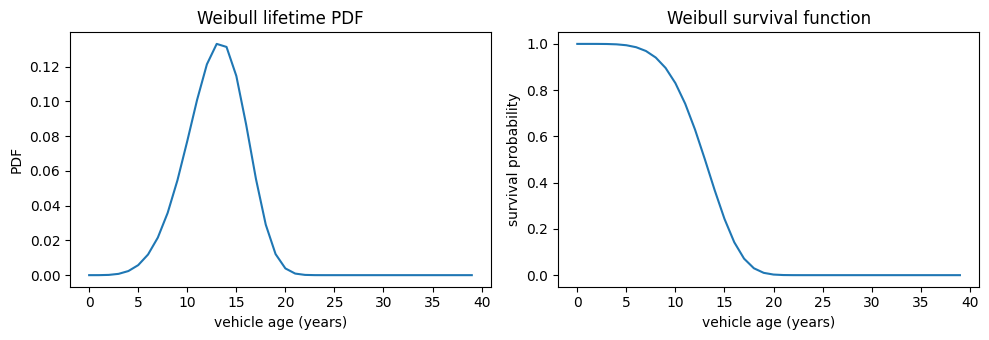

In [10]:
from scipy.stats import weibull_min

ages = np.arange(0, 40)
weibull_pdf_age = weibull_min.pdf(ages, c=WEIBULL_SHAPE, scale=WEIBULL_SCALE)
weibull_sf_age  = weibull_min.sf(ages, c=WEIBULL_SHAPE, scale=WEIBULL_SCALE)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(ages, weibull_pdf_age)
ax[0].set(xlabel="vehicle age (years)", ylabel="PDF", title="Weibull lifetime PDF")
ax[1].plot(ages, weibull_sf_age)
ax[1].set(xlabel="vehicle age (years)", ylabel="survival probability",
         title="Weibull survival function")
fig.tight_layout()

### Solve the dynamic stock model


In [11]:
dsm = StockDrivenDSM(dims=dims, stock=stock, lifetime_model=lifetime_model)
dsm.compute()

`StockDrivenDSM.compute()` populates `dsm.inflow` and `dsm.outflow`. Let's plot the three fleet variables together.

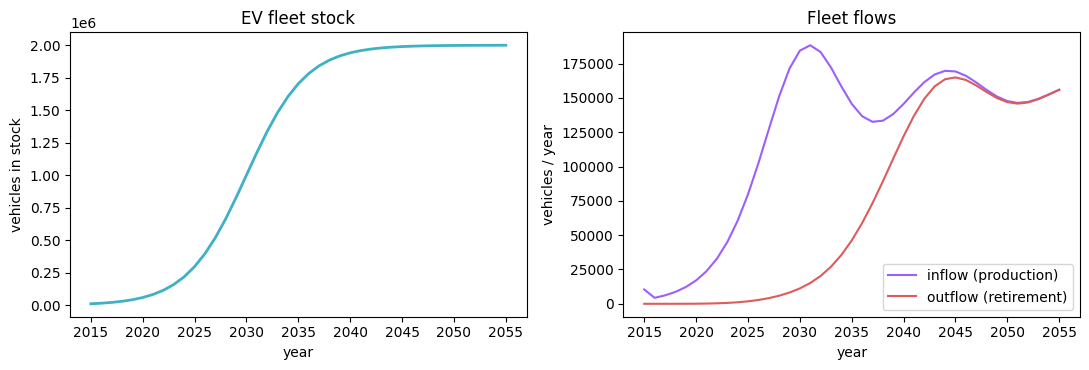

In [12]:
inflow_values  = dsm.inflow.values   # vehicles / year
outflow_values = dsm.outflow.values  # vehicles / year
stock_values_  = dsm.stock.values    # vehicles

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(years, stock_values_, color="#3fb1c5", lw=2)
ax[0].set(xlabel="year", ylabel="vehicles in stock", title="EV fleet stock")
ax[1].plot(years, inflow_values, label="inflow (production)", color="#9c5ffd")
ax[1].plot(years, outflow_values, label="outflow (retirement)", color="#dd5b5b")
ax[1].set(xlabel="year", ylabel="vehicles / year", title="Fleet flows")
ax[1].legend()
fig.tight_layout()

We will scope the LCA to vehicles whose **production** falls in the analysis window `[ANALYSIS_START, ANALYSIS_END]`. This keeps the fleet's life cycle entirely within the horizon of our background databases.

In [13]:
ANALYSIS_START = 2020
ANALYSIS_END   = 2050
FU_YEAR        = 2035   # anchoring year used as the TimexLCA starting datetime

mask = (years >= ANALYSIS_START) & (years <= ANALYSIS_END)

years_window  = years[mask]
inflow_window = inflow_values[mask]

n_total_inflow = inflow_window.sum()

print(f"Cohort window: {ANALYSIS_START}-{ANALYSIS_END} (inflow years).")
print(f"Total vehicles produced  {ANALYSIS_START}-{ANALYSIS_END}: {n_total_inflow:>12,.0f}")
print("Each cohort is then driven and retired according to the Weibull lifetime;")
print(f"those use and end-of-life events may extend past {ANALYSIS_END}.")

Cohort window: 2020-2050 (inflow years).
Total vehicles produced  2020-2050:    4,132,670
Each cohort is then driven and retired according to the Weibull lifetime;
those use and end-of-life events may extend past 2050.


## From flodym time series to `TemporalDistribution`s — cohort + age decomposition


We map the flodym output onto `bw_timex` using **two layers** of `TemporalDistribution`s:

1. A **cohort distribution** in calendar time on a single `fleet_service → fleet_driving` edge. Its weights are the inflow shares per year. This expands `fleet_driving` into one *consumer instance per cohort year* in the timeline.
2. **Age-relative distributions** on `fleet_driving`'s own exchanges:
   - on `fleet_driving → electricity`, the Weibull **survival function** over vehicle ages — each cohort uses electricity for as long as its vehicles are still on the road;
   - on `fleet_driving → used_ev`, the Weibull **retirement PDF** over vehicle ages — each cohort eventually retires.

The convolution `cohort_TD ⊛ age_TD` performed by `bw_timex` reproduces the aggregate stock × annual-mileage and the calendar-year retirement series, *and* every downstream exchange inherits a `date_consumer` equal to the cohort year. That is what lets us evaluate vintage-dependent properties later.

`bw_timex`'s convention is that `TD.amount × edge.amount` gives the absolute per-time quantity. We follow it consistently:

| Edge | `amount` | `TD.amount` (sums to 1) |
|---|---|---|
| `fleet_service → fleet_driving` | `n_total_inflow` (vehicles) | `inflow_window / n_total_inflow` |
| `fleet_driving → ev_production` | `1` (one build per vehicle) | implicit point-mass at age 0 |
| `fleet_driving → electricity` | `ANNUAL_MILEAGE × kWh/km × mean_lifetime` (kWh per vehicle) | `survival(age) / Σ survival` |
| `fleet_driving → used_ev` | `-1` (one retirement per vehicle) | `pdf(age) / Σ pdf` |


In [14]:
from bw_temporalis import TemporalDistribution

# 1) Cohort distribution: when each cohort enters the fleet (calendar years
#    relative to the FU anchor). Lives on fleet_service -> fleet_driving.
cohort_offsets = (years_window - FU_YEAR).astype("int64").astype("timedelta64[Y]")
cohort_shares  = inflow_window / inflow_window.sum()

td_cohort_inflow = TemporalDistribution(
    date=cohort_offsets,
    amount=cohort_shares,
)

# 2) Age-relative distributions inside fleet_driving (per cohort vehicle).
#    We drop ages whose weight is exactly zero: bw_timex's `abs_td` propagation
#    keeps zero-weight entries through the chain, which would create
#    unregistered foreground instances downstream.
ages = np.arange(0, 40)
weibull_sf  = weibull_min.sf(ages,  c=WEIBULL_SHAPE, scale=WEIBULL_SCALE)
weibull_pdf = weibull_min.pdf(ages, c=WEIBULL_SHAPE, scale=WEIBULL_SCALE)

# Use phase: survival probability normalised so the TD weights sum to 1.
# Combined with the edge amount = ANNUAL_MILEAGE * ELECTRICITY_CONSUMPTION * mean_lifetime
# below, the absolute per-(cohort, age) electricity is survival * annual kWh.
mean_lifetime_years = float(weibull_sf.sum())
sf_mask = weibull_sf > 0
td_use_age = TemporalDistribution(
    date=ages[sf_mask].astype("timedelta64[Y]"),
    amount=weibull_sf[sf_mask] / mean_lifetime_years,
)

# Retirement: Weibull PDF over ages, normalised to sum to 1.
pdf_mask = weibull_pdf > 0
td_retirement_age = TemporalDistribution(
    date=ages[pdf_mask].astype("timedelta64[Y]"),
    amount=weibull_pdf[pdf_mask] / weibull_pdf[pdf_mask].sum(),
)

A quick sanity check: the cohort TD shows when new vehicles enter, the use TD shows how each cohort's vehicle-years are spread over its lifetime, and the retirement TD shows when within that lifetime each cohort retires. The cohort TD lives on a calendar-year axis (relative to `FU_YEAR`); the age TDs live on a vehicle-age axis (offsets 0..39 years from each cohort).


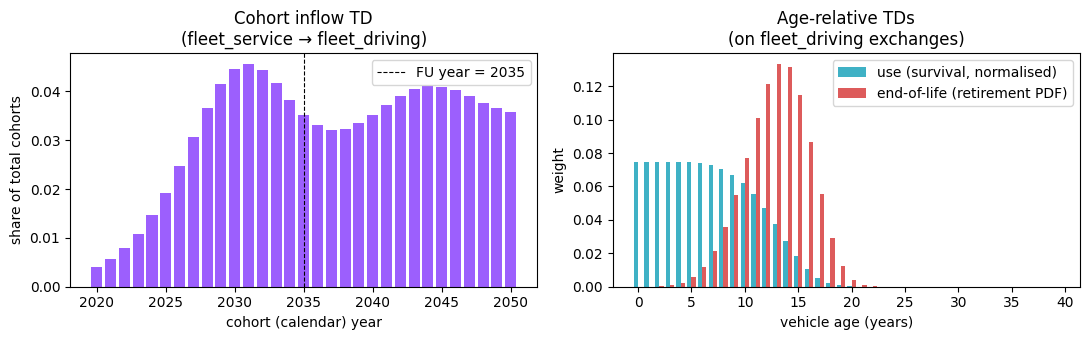

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].bar(years_window, td_cohort_inflow.amount, color="#9c5ffd")
axes[0].axvline(FU_YEAR, color="k", ls="--", lw=0.8, label=f"FU year = {FU_YEAR}")
axes[0].set(xlabel="cohort (calendar) year",
            ylabel="share of total cohorts",
            title="Cohort inflow TD\n(fleet_service → fleet_driving)")
axes[0].legend()

# Convert TD timedelta dates back to integer ages for plotting
use_ages   = td_use_age.date.astype("timedelta64[Y]").astype(int)
retire_ages = td_retirement_age.date.astype("timedelta64[Y]").astype(int)

axes[1].bar(use_ages - 0.2,    td_use_age.amount,        width=0.4, color="#3fb1c5",
            label="use (survival, normalised)")
axes[1].bar(retire_ages + 0.2, td_retirement_age.amount, width=0.4, color="#dd5b5b",
            label="end-of-life (retirement PDF)")
axes[1].set(xlabel="vehicle age (years)", ylabel="weight",
            title="Age-relative TDs\n(on fleet_driving exchanges)")
axes[1].legend()

fig.tight_layout()

## Building the fleet LCA model


The product system mirrors the standalone example, with one extra wrapping node. `fleet_service` is the FU-facing aggregator that *consumes `fleet_driving` once per cohort year*. The cohort TD lives on that edge, so each cohort year creates its own consumer-side instance of `fleet_driving`. Every exchange below `fleet_driving` then inherits a `date_consumer` equal to the cohort year, which is what makes vintage locking via `temporal_evolution_reference="consumer"` actually meaningful in this aggregate model.

```{mermaid}
flowchart LR
    glider_production(glider production):::ei-->ev_production
    powertrain_production(powertrain production):::ei-->ev_production
    battery_production(battery production):::ei-->ev_production
    fleet_service(fleet service):::fg-->|cohort inflow TD|fleet_driving
    ev_production(ev production):::fg-->fleet_driving
    electricity_generation(electricity generation):::ei-->|age survival TD|fleet_driving
    fleet_driving(fleet driving):::fg-->|age retirement TD|used_ev
    used_ev(used ev):::fg-->glider_eol(glider eol):::ei
    used_ev-->powertrain_eol(powertrain eol):::ei
    used_ev-->battery_eol(battery eol):::ei

    classDef ei color:#222832, fill:#3fb1c5, stroke:none;
    classDef fg color:#222832, fill:#9c5ffd, stroke:none;
```


In [16]:
if "foreground" in bd.databases:
    del bd.databases["foreground"]
foreground = bd.Database("foreground")
foreground.register()

### Foreground activities


In [17]:
ev_production = foreground.new_node(
    "ev_production", name="production of an electric vehicle", unit="unit",
)
ev_production["reference product"] = "electric vehicle"
ev_production.save()

# Per-cohort process: amounts on its outgoing edges are *per single vehicle*.
fleet_driving = foreground.new_node(
    "fleet_driving",
    name="lifetime driving of one cohort vehicle",
    unit="vehicle (cohort unit)",
)
fleet_driving["reference product"] = "vehicle lifetime driving"
fleet_driving.save()

# FU-facing aggregator: consumes one TD-distributed cohort of fleet_driving per year.
fleet_service = foreground.new_node(
    "fleet_service",
    name="aggregate transport service of the EV fleet",
    unit="fleet service over the analysis horizon",
)
fleet_service["reference product"] = "fleet service"
fleet_service.save()

used_ev = foreground.new_node(
    "used_ev", name="used electric vehicle", unit="unit",
)
used_ev["reference product"] = "used electric vehicle"
used_ev.save()

### EV production exchanges (per vehicle)


In [18]:
glider_production    = background_2020.get(code="glider")
powertrain_production = background_2020.get(code="powertrain")
battery_production   = background_2020.get(code="battery")

ev_production.new_edge(input=ev_production, amount=1, type="production").save()

glider_to_ev = ev_production.new_edge(
    input=glider_production, amount=MASS_GLIDER, type="technosphere"
)
powertrain_to_ev = ev_production.new_edge(
    input=powertrain_production, amount=MASS_POWERTRAIN, type="technosphere"
)
battery_to_ev = ev_production.new_edge(
    input=battery_production, amount=MASS_BATTERY, type="technosphere"
)

### End-of-life exchanges (per used vehicle)


In [19]:
glider_eol     = background_2020.get(name="glider_eol")
powertrain_eol = background_2020.get(name="powertrain_eol")
battery_eol    = background_2020.get(name="battery_eol")

used_ev.new_edge(input=used_ev, amount=-1, type="production").save()

used_ev_to_glider_eol = used_ev.new_edge(
    input=glider_eol, amount=-MASS_GLIDER, type="technosphere",
)
used_ev_to_powertrain_eol = used_ev.new_edge(
    input=powertrain_eol, amount=-MASS_POWERTRAIN, type="technosphere",
)
used_ev_to_battery_eol = used_ev.new_edge(
    input=battery_eol, amount=-MASS_BATTERY, type="technosphere",
)

### Fleet driving exchanges


Per cohort vehicle, `fleet_driving` consumes one EV production, drives `ANNUAL_MILEAGE` km/year over its (Weibull-distributed) lifetime, and produces one used vehicle. The fleet-level scaling lives entirely on the single `fleet_service → fleet_driving` edge, whose amount is `n_total_inflow` and whose TD will spread that total across cohort years.


In [20]:
electricity_production = background_2020.get(name="electricity")

fleet_service.new_edge(input=fleet_service, amount=1, type="production").save()
fleet_driving.new_edge(input=fleet_driving, amount=1, type="production").save()

# Aggregator -> per-cohort process. Total cohorts = n_total_inflow.
fleet_service_to_fleet_driving = fleet_service.new_edge(
    input=fleet_driving,
    amount=n_total_inflow,
    type="technosphere",
)
fleet_service_to_fleet_driving.save()

# One EV built per cohort vehicle.
ev_to_fleet_driving = fleet_driving.new_edge(
    input=ev_production,
    amount=1,
    type="technosphere",
)
ev_to_fleet_driving.save()

# Lifetime electricity per cohort vehicle = annual mileage * kWh/km * mean lifetime
# (mean_lifetime_years was computed in the TD cell from the Weibull SF).
electricity_to_fleet_driving = fleet_driving.new_edge(
    input=electricity_production,
    amount=ANNUAL_MILEAGE * ELECTRICITY_CONSUMPTION * mean_lifetime_years,
    type="technosphere",
)
electricity_to_fleet_driving.save()

# One retirement per cohort vehicle (used_ev has production amount -1).
fleet_driving_to_used_ev = fleet_driving.new_edge(
    input=used_ev,
    amount=-1,
    type="technosphere",
)
fleet_driving_to_used_ev.save()

### Adding temporal information


Three layers of `TemporalDistribution`s combine via convolution:

1. **Cohort layer** (calendar-year axis, relative to `FU_YEAR`): on `fleet_service → fleet_driving`. Splits the FU into one consumer instance of `fleet_driving` per cohort year.
2. **Age layer** (age axis, relative to each cohort year): on `fleet_driving → electricity` (survival) and `fleet_driving → used_ev` (retirement PDF). Spreads each cohort's lifetime over its age-resolved profile.
3. **Per-vehicle build/EOL lead-time layer** (already present in the standalone example): on the inner exchanges of `ev_production` and `used_ev`. These are timing offsets relative to *that* node's date — which, after step 1, *is* the cohort year for `ev_production` and the retirement year for `used_ev`.

After convolution, every downstream edge has a `date_consumer` equal to the cohort year and a `date_producer` equal to the calendar year the exchange happens.


In [21]:
td_glider_production = TemporalDistribution(
    date=np.array([-2, -1, 0], dtype="timedelta64[Y]"),
    amount=np.array([0.7, 0.1, 0.2]),
)

td_produce_powertrain_and_battery = TemporalDistribution(
    date=np.array([-1], dtype="timedelta64[Y]"),
    amount=np.array([1.0]),
)

td_treating_waste = TemporalDistribution(
    date=np.array([3], dtype="timedelta64[M]"),
    amount=np.array([1.0]),
)

In [22]:
# 1) Cohort layer — calendar-year TD on the aggregator edge.
fleet_service_to_fleet_driving["temporal_distribution"] = td_cohort_inflow
fleet_service_to_fleet_driving.save()

# 2) Age layer — age-relative TDs on fleet_driving's exchanges.
electricity_to_fleet_driving["temporal_distribution"] = td_use_age
electricity_to_fleet_driving.save()

fleet_driving_to_used_ev["temporal_distribution"] = td_retirement_age
fleet_driving_to_used_ev.save()

# 3) Per-vehicle build lead time inside ev_production.
glider_to_ev["temporal_distribution"]     = td_glider_production
glider_to_ev.save()
powertrain_to_ev["temporal_distribution"] = td_produce_powertrain_and_battery
powertrain_to_ev.save()
battery_to_ev["temporal_distribution"]    = td_produce_powertrain_and_battery
battery_to_ev.save()

# 3) Per-vehicle EOL treatment delay inside used_ev.
used_ev_to_glider_eol["temporal_distribution"]     = td_treating_waste
used_ev_to_glider_eol.save()
used_ev_to_powertrain_eol["temporal_distribution"] = td_treating_waste
used_ev_to_powertrain_eol.save()
used_ev_to_battery_eol["temporal_distribution"]    = td_treating_waste
used_ev_to_battery_eol.save()

### Vintage locking vs. system-wide efficiency

Because the cohort year is now propagated as the `date_consumer` of every exchange below `fleet_driving`, `temporal_evolution_factors` on the use-phase exchange takes on a clean, two-mode interpretation depending on `temporal_evolution_reference`:

- `"consumer"` → factor evaluated at the **cohort year**. A vehicle built in 2025 keeps its 2025 efficiency for the rest of its life, even when it is still driving in 2040 (true vintage locking).
- `"producer"` → factor evaluated at the **calendar year of consumption**. All vehicles, regardless of vintage, benefit from the latest efficiency value whenever they are driving (system-wide retrofit / learning).

Below we demonstrate vintage locking. Switching to system-wide learning is just a matter of changing `temporal_evolution_reference` to `"producer"`.


In [23]:
from datetime import datetime

# Vintage-locked efficiency: keyed by cohort year (consumer date).
vintage_efficiency_factors = {
    datetime(2020, 1, 1): 1.00,
    datetime(2030, 1, 1): 0.92,
    datetime(2040, 1, 1): 0.87,
    datetime(2050, 1, 1): 0.85,
}

electricity_to_fleet_driving["temporal_evolution_factors"]   = vintage_efficiency_factors
electricity_to_fleet_driving["temporal_evolution_reference"] = "consumer"
electricity_to_fleet_driving.save()

In [24]:
for db in bd.databases:
    bd.Database(db).process()

### Characterization method


In [25]:
bd.Method(("GWP", "example")).write(
    [
        (("biosphere", "CO2"), 1),
    ]
)

## Time-explicit fleet LCA with `TimexLCA`


In [26]:
from datetime import datetime
from bw_timex import TimexLCA

method = ("GWP", "example")

database_dates = {
    "background_2020": datetime.strptime("2020", "%Y"),
    "background_2030": datetime.strptime("2030", "%Y"),
    "background_2040": datetime.strptime("2040", "%Y"),
    "foreground": "dynamic",
}

We anchor the timeline at `FU_YEAR` (i.e. 2035) by passing it as `starting_datetime` to `build_timeline`. All the relative offsets in our `TemporalDistribution`s are interpreted with respect to that anchor.

In [27]:
fleet_service = bd.get_node(database="foreground", code="fleet_service")
tlca = TimexLCA({fleet_service: 1}, method, database_dates)

tlca.build_timeline(
    starting_datetime=datetime(FU_YEAR, 1, 1),
    temporal_grouping="year",
)

2026-05-03 10:50:56.451 | INFO     | bw_timex.timex_lca:__init__:122 - Initializing TimexLCA object...


2026-05-03 10:50:56.452 | INFO     | bw_timex.timex_lca:__init__:139 - Calculating base LCA...


2026-05-03 10:50:56.473 | INFO     | bw_timex.timex_lca:__init__:156 - Collecting node infos...


2026-05-03 10:50:56.482 | INFO     | bw_timex.timex_lca:build_timeline:252 - No edge filter function provided. Skipping all edges in background databases.


2026-05-03 10:50:56.484 | INFO     | bw_timex.timex_lca:build_timeline:268 - Creating activity time mapping...


...

2026-05-03 10:50:57.921 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:562 - Reference date 2089-01-01 00:00:00 is higher than all provided dates. Data will be taken from the closest lower year.


2026-05-03 10:50:57.921 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:562 - Reference date 2089-01-01 00:00:00 is higher than all provided dates. Data will be taken from the closest lower year.


2026-05-03 10:50:57.921 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:562 - Reference date 2089-01-01 00:00:00 is higher than all provided dates. Data will be taken from the closest lower year.


2026-05-03 10:50:57.923 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:562 - Reference date 2089-01-01 00:00:00 is higher than all provided dates. Data will be taken from the closest lower year.


,date_producer,producer_name,date_consumer,consumer_name,amount,temporal_market_shares
0,2018-01-01,glider,2020-01-01,production of an electric vehicle,588.0,{'background_2020': 1}
1,2019-01-01,glider,2020-01-01,production of an electric vehicle,84.0,{'background_2020': 1}
2,2019-01-01,powertrain,2020-01-01,production of an electric vehicle,80.0,{'background_2020': 1}
3,2019-01-01,battery,2020-01-01,production of an electric vehicle,280.0,{'background_2020': 1}
4,2019-01-01,glider,2021-01-01,production of an electric vehicle,588.0,{'background_2020': 1}
...,...,...,...,...,...,...
2869,2089-01-01,electricity,2050-01-01,lifetime driving of one cohort vehicle,0.0,{'background_2040': 1}
2870,2089-01-01,used electric vehicle,2050-01-01,lifetime driving of one cohort vehicle,-0.0,None
2871,2089-01-01,glider_eol,2089-01-01,used electric vehicle,-840.0,{'background_2040': 1}
2872,2089-01-01,powertrain_eol,2089-01-01,used electric vehicle,-80.0,{'background_2040': 1}


### Inventory and static score


In [28]:
tlca.lci()
tlca.static_lcia()
print(f"Time-explicit fleet GWP: {tlca.static_score:,.0f} kg CO2-eq")
print(f"Static (2020 background) fleet GWP: {tlca.base_lca.score:,.0f} kg CO2-eq")

2026-05-03 10:50:57.978 | INFO     | bw_timex.timex_lca:lci:385 - Expanding matrices...


2026-05-03 10:51:07.801 | INFO     | bw_timex.timex_lca:lci:404 - Calculating dynamic inventory...


Time-explicit fleet GWP: 37,275,325,891 kg CO2-eq
Static (2020 background) fleet GWP: 120,320,353,543 kg CO2-eq


On a per-vehicle basis the time-explicit score is much smaller, because most of the fleet is produced and driven in years where the background system has decarbonised compared to 2020.

In [29]:
print(f"Per-vehicle GWP, time-explicit: "
      f"{tlca.static_score / n_total_inflow:,.0f} kg CO2-eq / vehicle")
print(f"Per-vehicle GWP, static (2020):  "
      f"{tlca.base_lca.score / n_total_inflow:,.0f} kg CO2-eq / vehicle")

Per-vehicle GWP, time-explicit: 9,020 kg CO2-eq / vehicle
Per-vehicle GWP, static (2020):  29,114 kg CO2-eq / vehicle


### Dynamic characterization


We characterize the dynamic inventory using the IPCC AR6 CO2 radiative-forcing function (reusing the `dynamic_characterization` package as in the standalone notebook).

In [30]:
from dynamic_characterization.ipcc_ar6.radiative_forcing import characterize_co2

characterization_functions = {
    bd.get_node(code="CO2").id: characterize_co2,
}

tlca.dynamic_lcia(
    metric="radiative_forcing",
    fixed_time_horizon=True,
    characterization_functions=characterization_functions,
)
print(f"Cumulative fleet radiative forcing: {tlca.dynamic_score:.3e} W/m²")

Cumulative fleet radiative forcing: 3.290e-03 W/m²


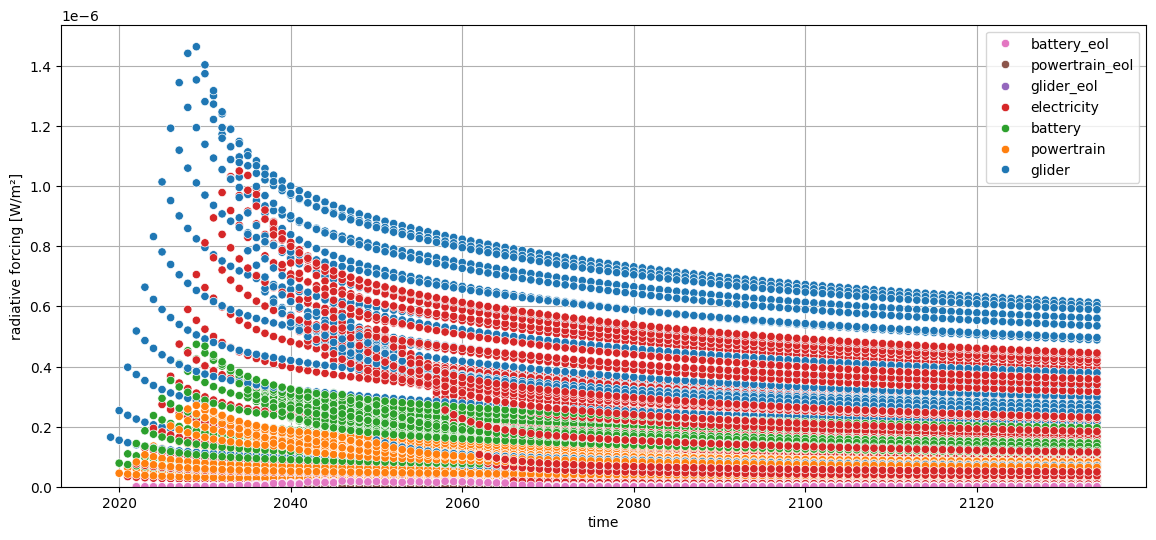

In [31]:
tlca.plot_dynamic_characterized_inventory(sum_emissions_within_activity=True)

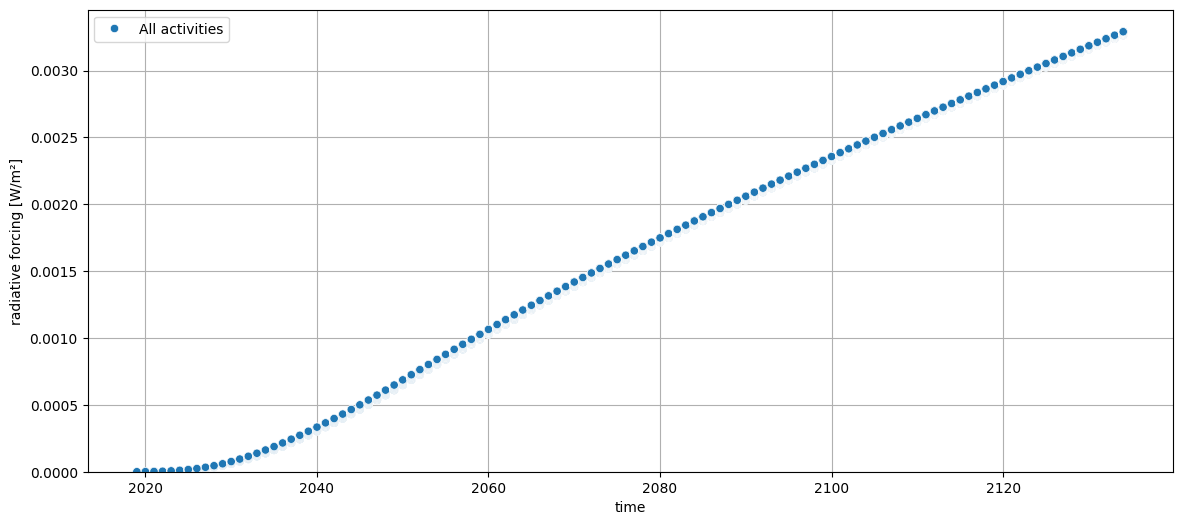

In [32]:
tlca.plot_dynamic_characterized_inventory(sum_activities=True, cumsum=True)

And the same in GWP units, with a 100-year time horizon:

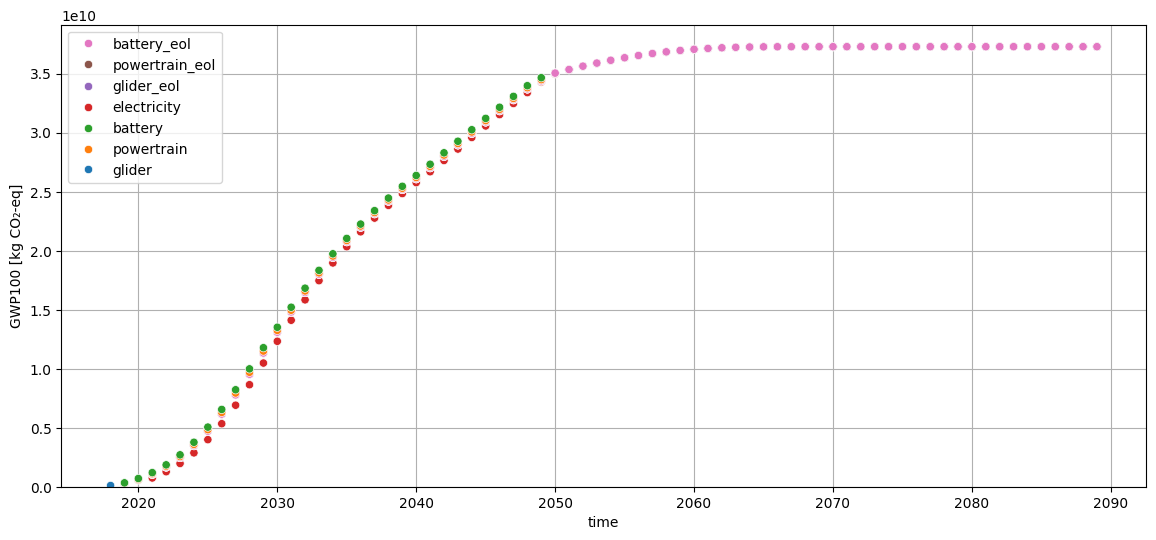

In [33]:
tlca.dynamic_lcia(
    metric="GWP",
    fixed_time_horizon=False,
    time_horizon=100,
    characterization_functions=characterization_functions,
)
tlca.plot_dynamic_characterized_inventory(sum_emissions_within_activity=True, cumsum=True)

## Waterfall comparison: static vs. time-explicit vs. prospective


To put the time-explicit fleet result in context, we compare it to two static bookends:

- a **static (2020) score**: the whole fleet sourced from `background_2020`,
- a **prospective (2040) score**: the whole fleet sourced from `background_2040`.

We re-use `bw_timex.utils.plot_characterized_inventory_as_waterfall`, which expects first-level contribution scores per background activity. To get them, we walk through the fleet's exchanges (and the sub-exchanges of `ev_production` and `used_ev`) and run a static LCIA for each one. The middle stack of the waterfall comes from the GWP100 time-explicit characterized inventory we just computed.

In [34]:
import bw2calc as bc
from bw_timex.utils import plot_characterized_inventory_as_waterfall

# Single fleet_service -> fleet_driving edge carries the cohort-total scaling.
cohort_multiplier = next(iter(fleet_service.technosphere())).amount

static_scores = {}
for exc in fleet_driving.technosphere():
    if exc.input == ev_production:
        for subexc in exc.input.technosphere():
            tlca.base_lca.lcia(demand={subexc.input.id:
                cohort_multiplier * exc.amount * subexc.amount
                * subexc.input.rp_exchange().amount})
            static_scores[subexc.input["name"]] = tlca.base_lca.score
    elif exc.input == used_ev:
        for subexc in exc.input.technosphere():
            tlca.base_lca.lcia(demand={subexc.input.id:
                cohort_multiplier * exc.amount * subexc.amount
                * subexc.input.rp_exchange().amount})
            static_scores[subexc.input["name"]] = tlca.base_lca.score
    else:
        tlca.base_lca.lcia(demand={exc.input.id: cohort_multiplier * exc.amount})
        static_scores[exc.input["name"]] = tlca.base_lca.score

For the prospective scores we copy the foreground processes and relink every background input to its 2040 counterpart, then redo the same first-level contribution analysis.

In [35]:
for code in ("prospective_fleet_service",
             "prospective_fleet_driving",
             "prospective_ev_production",
             "prospective_used_ev"):
    if ("foreground", code) in bd.Database("foreground"):
        foreground.get(code=code).delete()

prospective_fleet_service = fleet_service.copy(
    code="prospective_fleet_service",
    name="aggregate transport service of the EV fleet (2040 background)",
)
prospective_fleet_driving = fleet_driving.copy(
    code="prospective_fleet_driving",
    name="lifetime driving of one cohort vehicle (2040 background)",
)
prospective_ev_production = ev_production.copy(
    code="prospective_ev_production",
    name="production of an electric vehicle (2040 background)",
)
prospective_used_ev = used_ev.copy(
    code="prospective_used_ev",
    name="used electric vehicle (2040 background)",
)

# Re-link the prospective service edge to the prospective fleet_driving copy.
service_edge = next(iter(prospective_fleet_service.technosphere()))
service_edge.input = prospective_fleet_driving
service_edge.save()

# Re-link prospective_fleet_driving's foreground sub-edges and its background
# electricity input to the 2040 background.
for exc in prospective_fleet_driving.technosphere():
    if exc.input == ev_production:
        exc.input = prospective_ev_production
        exc.save()
    elif exc.input == used_ev:
        exc.input = prospective_used_ev
        exc.save()
    else:
        exc.input = bd.get_node(
            database=background_2040.name,
            name=exc.input["name"],
            product=exc.input["reference product"],
            location=exc.input["location"],
        )
        exc.save()

# Re-link backgrounds for prospective ev_production and used_ev.
for parent in (prospective_ev_production, prospective_used_ev):
    for subexc in parent.technosphere():
        subexc.input = bd.get_node(
            database=background_2040.name,
            name=subexc.input["name"],
            product=subexc.input["reference product"],
            location=subexc.input["location"],
        )
        subexc.save()

prospective_scores = {}
lca = bc.LCA({prospective_fleet_service.key: 1}, method)
lca.lci(factorize=True)

prospective_cohort_multiplier = next(iter(prospective_fleet_service.technosphere())).amount

for exc in prospective_fleet_driving.technosphere():
    if exc.input["name"] in (prospective_ev_production["name"],
                            prospective_used_ev["name"]):
        for subexc in exc.input.technosphere():
            lca.lcia(demand={subexc.input.id:
                prospective_cohort_multiplier * exc.amount * subexc.amount
                * subexc.input.rp_exchange().amount})
            prospective_scores[subexc.input["name"]] = lca.score
    else:
        lca.lcia(demand={exc.input.id: prospective_cohort_multiplier * exc.amount})
        prospective_scores[exc.input["name"]] = lca.score

print(f"Static (2020)      fleet GWP: {sum(static_scores.values()):,.0f} kg CO2-eq")
print(f"Time-explicit      fleet GWP: {tlca.dynamic_score:,.0f} kg CO2-eq")
print(f"Prospective (2040) fleet GWP: {sum(prospective_scores.values()):,.0f} kg CO2-eq")

Static (2020)      fleet GWP: 120,320,349,842 kg CO2-eq
Time-explicit      fleet GWP: 37,275,325,891 kg CO2-eq
Prospective (2040) fleet GWP: 26,029,147,711 kg CO2-eq


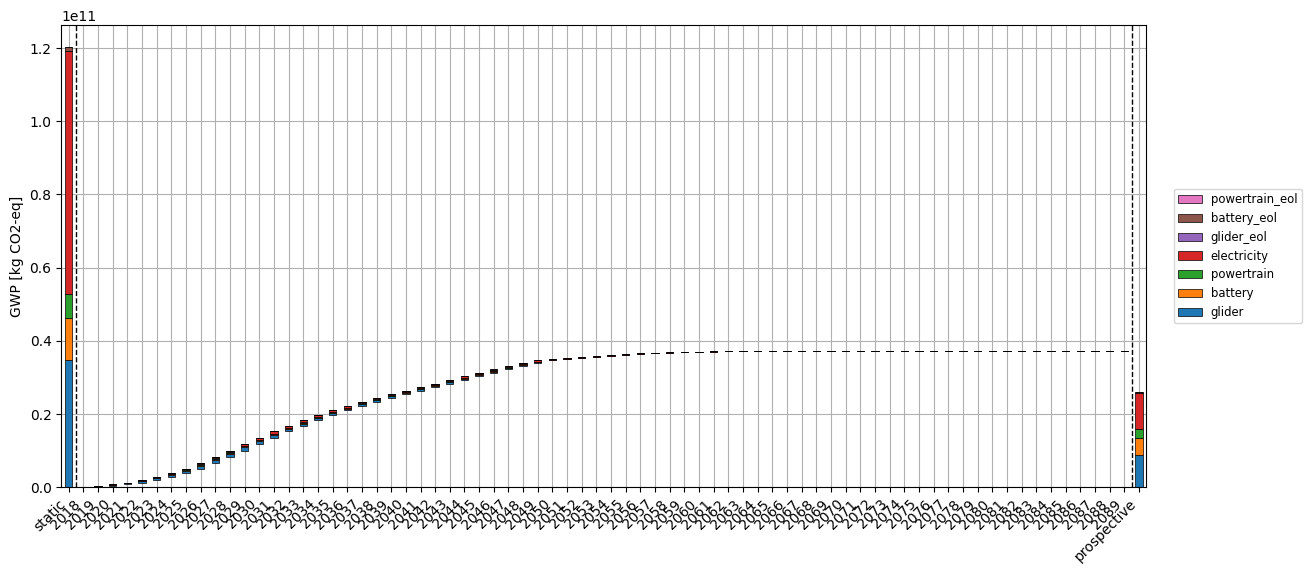

In [36]:
order_stacked_activities = [
    glider_production["name"],
    battery_production["name"],
    powertrain_production["name"],
    electricity_production["name"],
    glider_eol["name"],
    battery_eol["name"],
    powertrain_eol["name"],
]

plot_characterized_inventory_as_waterfall(
    tlca,
    static_scores=static_scores,
    prospective_scores=prospective_scores,
    order_stacked_activities=order_stacked_activities,
)

The leftmost bar represents the fleet's GWP100 if every background process were sourced from `background_2020`, the rightmost bar from `background_2040`. The stacked bars in between are the time-explicit fleet emissions, broken down by year and contributing background activity. Together they show how the fleet's footprint shifts as the underlying electricity and material production decarbonise.

## Wrap-up


### What the cohort-via-TD pattern lets you express

Because we encode the cohort year as a TD on a single foreground edge (and not as a per-cohort foreground activity), the same compact model supports a clear menu of vintage interpretations on any exchange below `fleet_driving`:

- **Calendar-year background tracking** — already automatic via the time-explicit interpolation between `background_2020/30/40`, evaluated at each `date_producer`.
- **System-wide foreground learning** — `temporal_evolution_factors` with `reference="producer"`. Old and new cohorts both benefit from later improvements when their use exchanges land in later years.
- **Vintage-locked foreground efficiency** — `temporal_evolution_factors` with `reference="consumer"`, as demonstrated above. Each cohort keeps the value at its own cohort year forever.
- **Per-vehicle internal timing** — the lead-time TDs on `ev_production`'s and `used_ev`'s sub-exchanges still apply per cohort, since their parent's date is the cohort year (build) or the retirement year.

For richer cohort effects (e.g. distinct material composition per vintage), drop the cohort TD and instead create per-vintage `ev_production_<year>` activities. The structure here is the natural single-aggregate baseline; the per-cohort variant is the natural disaggregated extension.


We replaced the single-vehicle, fixed-lifetime assumption from the standalone notebook by a fleet-level model in which the **timing** of production, driving and retirement is derived from a dynamic stock model with a Weibull lifetime, computed with `flodym`. Crucially, instead of pre-aggregating stock and outflow into calendar-year TDs, we feed `bw_timex` two thinner TDs that combine via convolution: a **cohort distribution** on `fleet_service → fleet_driving` and **age-relative** survival/retirement TDs on `fleet_driving`'s exchanges. That recovers the same calendar-year aggregates while exposing the cohort year as the `date_consumer` of every downstream exchange — which is the hook that makes vintage-locked `temporal_evolution_factors` meaningful.

From here you can experiment with:

- different stock trajectories (e.g. faster ramp-up, smaller saturation),
- different lifetime distributions (`NormalLifetime`, `LogNormalLifetime`, `FoldedNormalLifetime`, `FixedLifetime`) and their parameters,
- richer foreground systems (battery replacement, second-life batteries) by adding more stocks to the flodym model and corresponding exchanges in the brightway model,
- per-vintage `ev_production_<year>` activities if cohort-specific bills of materials matter.
